In [71]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd, norm
from numba import njit
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from utilities_rbf import sampling_domain_2d  # (keep your own helpers if needed)
import scipy.io

# -------------------------
# Parameters
# -------------------------
N_side = 20
N = N_side**2
T = 8.0
zeta = 2.0
M_side = int(np.sqrt(zeta * N))
tau = 1e-12
M = M_side**2

sampling_choice = 'random'
seed_value = 123456
sigma_scale_random_sampling = 1e-8

def c_from_T(T, tau):
    return np.pi / (T * np.sqrt(2 * np.log(1 + tau**(-2))))

c = c_from_T(T, tau)
print(f'c value using c(T, tau): {c:.3f}')
b = c * N
print(f"b (kernel shape) = {b:.3f}")

max_iter = 50_000
tol = 1e-6
L = 1.0

# ADMM / BC params
rho = 20.3
h = L/M_side
mu = 10/h**2            # 0 -> hard projection to obstacle; >0 -> soft (Moreau–Yosida)
beta_bc = 1e6       # Dirichlet penalty
eps_reg = 1e-8       # tiny Tikhonov on lhs
alpha = 1.0         # over-relaxation (1.0 = off)

# -------------------------
# Domain
# -------------------------
X, Y, collocation_pts, boundary_mask, interior_mask = sampling_domain_2d(
    M_side, M_side,
    seed_x=seed_value,
    seed_y=seed_value,
    jitter_frac=sigma_scale_random_sampling
)


#DATA = scipy.io.loadmat('./RadialBasis/2D_NonLinearObstacleProblem/2Dstochastic_data_ObstacleProblem.mat')
#X = np.array(DATA['sampleX'])
#Y = np.array(DATA['sampleY'])
#psi = np.array(DATA['psiD'])
#psi = np.reshape(psi, [-1,1]).ravel()
#g = np.reshape(psi, [-1,1])
#X_flat = np.reshape(X,[-1,1]).squeeze()
#Y_flat = np.reshape(Y,[-1,1]).squeeze()
#collocation_pts = np.stack([X_flat,Y_flat],1).squeeze()
#input_boundary_x = np.concatenate([X[0,:],X[-1,:],X[:,0],X[:,-1]])
#input_boundary_y = np.concatenate([Y[0,:],Y[-1,:],Y[:,0],Y[:,-1]])
#boundary_pts = np.stack([input_boundary_x,input_boundary_y],1)
#M = collocation_pts.shape[0]
#x_mask = (np.isclose(collocation_pts[:,0], 0, atol=tol) | np.isclose(collocation_pts[:,0], L, atol=tol))
#y_mask = (np.isclose(collocation_pts[:,1], 0, atol=tol) | np.isclose(collocation_pts[:,1], L, atol=tol))
#boundary_mask = x_mask | y_mask
#interior_mask = ~boundary_mask


# RBF centers (on the square)
lower_a, upper_b = 0.0, L
L_half = 0.5 * (upper_b - lower_a)
q_mid = 0.5 * (lower_a + upper_b)
T_cent = 1.0
cx = np.linspace(q_mid - T_cent * L_half, q_mid + T_cent * L_half, N_side)
CY, CX = np.meshgrid(cx, cx)
centers = np.column_stack((CX.ravel(), CY.ravel()))

# -------------------------
# Obstacle φ3 (piecewise): diamond, circle, and a horizontal segment
# -------------------------


def psi(xy, w=0.04, h_piece=5.0,  h_circle=4.5, r_circle=np.sqrt(0.001)):
    """
    Piece-wise block + circular bumps on [0,1]^2:
    """
    x, y = xy[:,0], xy[:,1]
    psi_vals = np.zeros_like(x)

    # Left block region
    mask_left = (np.abs(x-0.6) + np.abs(y - 0.6) <= w)
    psi_vals[mask_left] = h_piece



    # Circular bump region
    dx = x - 0.5
    dy = y - 0.4
    mask_circle = (dx*dx + dy*dy) < r_circle**2
    psi_vals[mask_circle] = h_circle

    h = L / M_side 
    thickness = 0.57
    eps_line = thickness * h 
    # "Line" y=0.57, with finite thickness, x-interval (0.075, 0.13)
    mask_line = (np.abs(y - 0.57) < eps_line) & (x > 0.075) & (x < 0.13)
    psi_vals[mask_line] = np.maximum(psi_vals[mask_line], h_circle)

    return psi_vals



def psi_phi3(xy, eps_line=None):
    """
    Implements:
      5.0  if |x-0.6|+|y-0.6| < 0.04   (L1 'diamond')
      4.5  if (x-0.6)^2 + (y-0.25)^2 < 0.001  (circle)
      4.5  if y = 0.57 and 0.075 < x < 0.13   (line segment; approximated with a thin band)
      0    otherwise

    eps_line: thickness for the y=0.57 line (defaults to 1.5*h)
    """
    if eps_line is None:
        thickness = 0.57
        eps_line = (thickness) * h

    x, y = xy[:, 0], xy[:, 1]
    out = np.zeros_like(x)

    # Diamond (L1 ball)
    mask_diamond = (np.abs(x - 0.6) + np.abs(y - 0.6)) < 0.04
    out[mask_diamond] = np.maximum(out[mask_diamond], 5.0)

    # Circle
    mask_circle = (x - 0.6) ** 2 + (y - 0.25) ** 2 < 0.001
    out[mask_circle] = np.maximum(out[mask_circle], 4.5)

    # "Line" y=0.57, with finite thickness, x-interval (0.075, 0.13)
    mask_line = (np.abs(y - 0.57) < eps_line) & (x > 0.075) & (x < 0.13)
    out[mask_line] = np.maximum(out[mask_line], 4.5)

    return out

psi_vals = psi(collocation_pts)

# -------------------------
# Numba-accelerated RBFs
# -------------------------
@njit
def rbf_fast(xy, centers, b):
    M, N = xy.shape[0], centers.shape[0]
    out = np.empty((M, N))
    for i in range(M):
        for j in range(N):
            dx = xy[i, 0] - centers[j, 0]
            dy = xy[i, 1] - centers[j, 1]
            r2 = dx * dx + dy * dy
            out[i, j] = np.exp(-b * b * r2)
    return out

@njit
def rbf_grad_fast(xy, centers, b):
    """
    Gradients of Gaussian RBF: phi = exp(-b^2 r^2)
      dphi/dx = -2 b^2 (x - cx) * phi
      dphi/dy = -2 b^2 (y - cy) * phi
    Returns Gx, Gy with shape (M, N)
    """
    M, N = xy.shape[0], centers.shape[0]
    Gx = np.empty((M, N))
    Gy = np.empty((M, N))
    for i in range(M):
        xi, yi = xy[i, 0], xy[i, 1]
        for j in range(N):
            dx = xi - centers[j, 0]
            dy = yi - centers[j, 1]
            r2 = dx * dx + dy * dy
            phi = np.exp(-b * b * r2)
            coef = -2.0 * b * b
            Gx[i, j] = coef * dx * phi
            Gy[i, j] = coef * dy * phi
    return Gx, Gy


# ===== Wendland C2 basis =====

@njit
def _wendland_c2_val(q):
    # phi(q) = (1 - q)^4 (4q + 1) for 0 <= q <= 1, else 0
    if 0.0 <= q <= 1.0:
        t = 1.0 - q
        return (t*t*t*t) * (4.0*q + 1.0)
    else:
        return 0.0

@njit
def rbf_wendland_c2(xy, centers, kappa):
    """
    Dense Phi matrix for Wendland C2 in 2D.
    xy:      (M,2) collocation points
    centers: (N,2) RBF centers
    kappa:   support radius (>0)
    returns: (M,N) Phi
    """
    M, N = xy.shape[0], centers.shape[0]
    Phi = np.zeros((M, N))
    inv_k = 1.0 / kappa
    for i in range(M):
        xi, yi = xy[i, 0], xy[i, 1]
        for j in range(N):
            dx = xi - centers[j, 0]
            dy = yi - centers[j, 1]
            r = np.sqrt(dx*dx + dy*dy)
            q = r * inv_k
            if q <= 1.0:
                # (1 - q)^4 (4q + 1)
                t = 1.0 - q
                Phi[i, j] = (t*t*t*t) * (4.0*q + 1.0)
            # else remains 0
    return Phi

@njit
def rbf_wendland_c2_grad(xy, centers, kappa):
    """
    Gradients for Wendland C2 in 2D.
    Using: grad phi = -20 * (1 - q)^3 / kappa^2 * [dx, dy] for 0<q<=1 ; 0 otherwise
    """
    M, N = xy.shape[0], centers.shape[0]
    Gx = np.zeros((M, N))
    Gy = np.zeros((M, N))
    inv_k = 1.0 / kappa
    inv_k2 = inv_k * inv_k
    for i in range(M):
        xi, yi = xy[i, 0], xy[i, 1]
        for j in range(N):
            dx = xi - centers[j, 0]
            dy = yi - centers[j, 1]
            r = np.sqrt(dx*dx + dy*dy)
            q = r * inv_k
            if q <= 1.0:
                t = 1.0 - q
                coeff = -20.0 * (t*t*t) * inv_k2   # -20 (1-q)^3 / kappa^2
                Gx[i, j] = coeff * dx
                Gy[i, j] = coeff * dy
            # else remains 0
    return Gx, Gy

h_c = 1.0 / (N_side - 1)     # average center spacing on [0,1]
kappa = 3.0 * h_c            # try 2.5–4.0 × h_c; increase for smoother


#Phi_raw = rbf_wendland_c2(collocation_pts, centers, kappa)
#Gx_raw, Gy_raw = rbf_wendland_c2_grad(collocation_pts, centers, kappa)

# keep your normalization if you like:
#Phi = Phi_raw / np.sqrt(N)
#Gx  = Gx_raw  / np.sqrt(N)
#Gy  = Gy_raw  / np.sqrt(N)


Phi_raw = rbf_fast(collocation_pts, centers, b)
Phi = Phi_raw / np.sqrt(N)

Gx_raw, Gy_raw = rbf_grad_fast(collocation_pts, centers, b)
Gx = Gx_raw / np.sqrt(N)
Gy = Gy_raw / np.sqrt(N)

dx_cells = L / (M_side)  # for weak-form scaling

# -------------------------
# Energy (weak form)
# -------------------------
A1 = dx_cells**2 * (Gx.T @ Gx + Gy.T @ Gy)

# -------------------------
# Boundary data (homogeneous Dirichlet)
# -------------------------
g_bc = np.zeros(np.sum(boundary_mask))
Phi_bc = Phi[boundary_mask, :]

# -------------------------
# Normal equations (lhs) for w-update
# -------------------------
A = A1 + beta_bc * (Phi_bc.T @ Phi_bc)
lhs = A + rho * (Phi.T @ Phi) + eps_reg * np.eye(N)

# TSVD solver
U, S, VT = svd(lhs, full_matrices=False)
svd_tol = tau * np.max(S)
S_inv = np.where(S > svd_tol, 1.0 / S, 0.0)

def svd_solve(U, S_inv, VT, bvec):
    return VT.T @ (S_inv * (U.T @ bvec))

# -------------------------
# ADMM initialization
# -------------------------
w = np.zeros(N)
v = Phi @ w
z = np.zeros(M)
primal_residuals, dual_residuals = [], []

stall_rel = 1e-8
stall_patience = 20_000
tiny = 1e-30
best_prim = np.inf
best_dual = np.inf
stall_cnt = 0

# -------------------------
# ADMM iteration
# -------------------------
for it in range(max_iter):
    # w-update
    rhs = rho * Phi.T @ (v - z) + beta_bc * (Phi_bc.T @ g_bc)
    w_new = svd_solve(U, S_inv, VT, rhs)

    # v-update (over-relaxed)
    a = alpha * (Phi @ w_new) + (1 - alpha) * v + z

    v_new = a.copy()

    # boundary clamp
    v_new[boundary_mask] = g_bc

    # interior obstacle
    a_int   = a[interior_mask]
    psi_int = psi_vals[interior_mask]

    if mu <= 0.0:
        # HARD projection
        v_new[interior_mask] = np.maximum(a_int, psi_int)
    else:
        # thresholding
        below = a_int < psi_int
        v_soft = (rho * a_int + mu * psi_int) / (rho + mu)
        v_int = a_int.copy()
        v_int[below] = v_soft[below]
        v_new[interior_mask] = v_int

    # dual update (only interior)
    z_new = z.copy()
    residual = (Phi @ w_new - v_new)
    z_new[interior_mask] += residual[interior_mask]
    z_new[boundary_mask] = 0.0

    # diagnostics
    r_k = Phi @ w_new - v_new
    s_k = rho * Phi.T @ (v_new - v)

    norm_u = norm(Phi @ w_new)
    norm_v = norm(v_new)
    primal_res = norm(r_k) / max(norm_u , norm_v, tol)
    dual_res = norm(s_k) / max(norm(rho * Phi.T @ z), tol)

    primal_residuals.append(primal_res)
    dual_residuals.append(dual_res)

    if (it % 500 == 0) or (primal_res < tol and dual_res < tol):
        print(f"Iter {it}: Primal Residual = {primal_res:.2e}, Dual Residual = {dual_res:.2e}")
    if primal_res < tol and dual_res < tol:
        print(f"Converged at iteration {it}")
        w, v, z = w_new, v_new, z_new
        break

    # early-stopping on stall
    imp_prim = (best_prim - primal_res) / (best_prim if best_prim > tiny else tiny)
    imp_dual = (best_dual - dual_res) / (best_dual if best_dual > tiny else tiny)

    improved = False
    if imp_prim > stall_rel:
        best_prim = primal_res
        improved = True
    if imp_dual > stall_rel:
        best_dual = dual_res
        improved = True

    if improved:
        stall_cnt = 0
    else:
        stall_cnt += 1
        if stall_cnt >= stall_patience:
            print(f"Early stop (stall) at iter {it}: no ≥{stall_rel:.1e} rel improvement "
                  f"in prim/dual for {stall_cnt} consecutive iterations.")
            w, v, z = w_new, v_new, z_new
            break

    w, v, z = w_new, v_new, z_new

# -------------------------
# Post-processing & plots
# -------------------------
# dense grid for visualization
M_plot = 800
x_plot = np.linspace(0, L, M_plot)
X_plot, Y_plot = np.meshgrid(x_plot, x_plot)
collocation_pts_plot = np.column_stack((X_plot.ravel(), Y_plot.ravel()))

Phi_raw_plot = rbf_fast(collocation_pts_plot, centers, b)
#Phi_raw_plot = rbf_wendland_c2(collocation_pts_plot, centers, kappa)
Phi_plot = Phi_raw_plot / np.sqrt(N)

u_rbf = Phi_plot @ w
U_rbf = u_rbf.reshape(M_plot, M_plot)

Psi_plot = psi(collocation_pts_plot).reshape(M_plot, M_plot)

def softplus(x, kappa=100.0):
    return (1.0 / kappa) * np.log1p(np.exp(kappa * x))

gap_smooth = softplus(U_rbf - Psi_plot, kappa=5.0)


c value using c(T, tau): 0.037
b (kernel shape) = 14.941
Iter 0: Primal Residual = 1.00e+00, Dual Residual = 2.77e+07


/tmp/ipykernel_775208/180878313.py:372: RuntimeWarning: invalid value encountered in scalar divide
  imp_prim = (best_prim - primal_res) / (best_prim if best_prim > tiny else tiny)
/tmp/ipykernel_775208/180878313.py:373: RuntimeWarning: invalid value encountered in scalar divide
  imp_dual = (best_dual - dual_res) / (best_dual if best_dual > tiny else tiny)


Iter 500: Primal Residual = 6.27e-06, Dual Residual = 1.42e-01
Iter 1000: Primal Residual = 1.37e-06, Dual Residual = 4.15e-02
Iter 1500: Primal Residual = 3.51e-07, Dual Residual = 1.12e-02
Iter 2000: Primal Residual = 1.12e-07, Dual Residual = 2.97e-03
Iter 2500: Primal Residual = 7.10e-08, Dual Residual = 7.83e-04
Iter 3000: Primal Residual = 6.72e-08, Dual Residual = 2.06e-04
Iter 3500: Primal Residual = 6.70e-08, Dual Residual = 5.41e-05
Iter 4000: Primal Residual = 6.69e-08, Dual Residual = 1.42e-05
Iter 4500: Primal Residual = 6.69e-08, Dual Residual = 3.74e-06
Iter 4994: Primal Residual = 6.69e-08, Dual Residual = 9.98e-07
Converged at iteration 4994


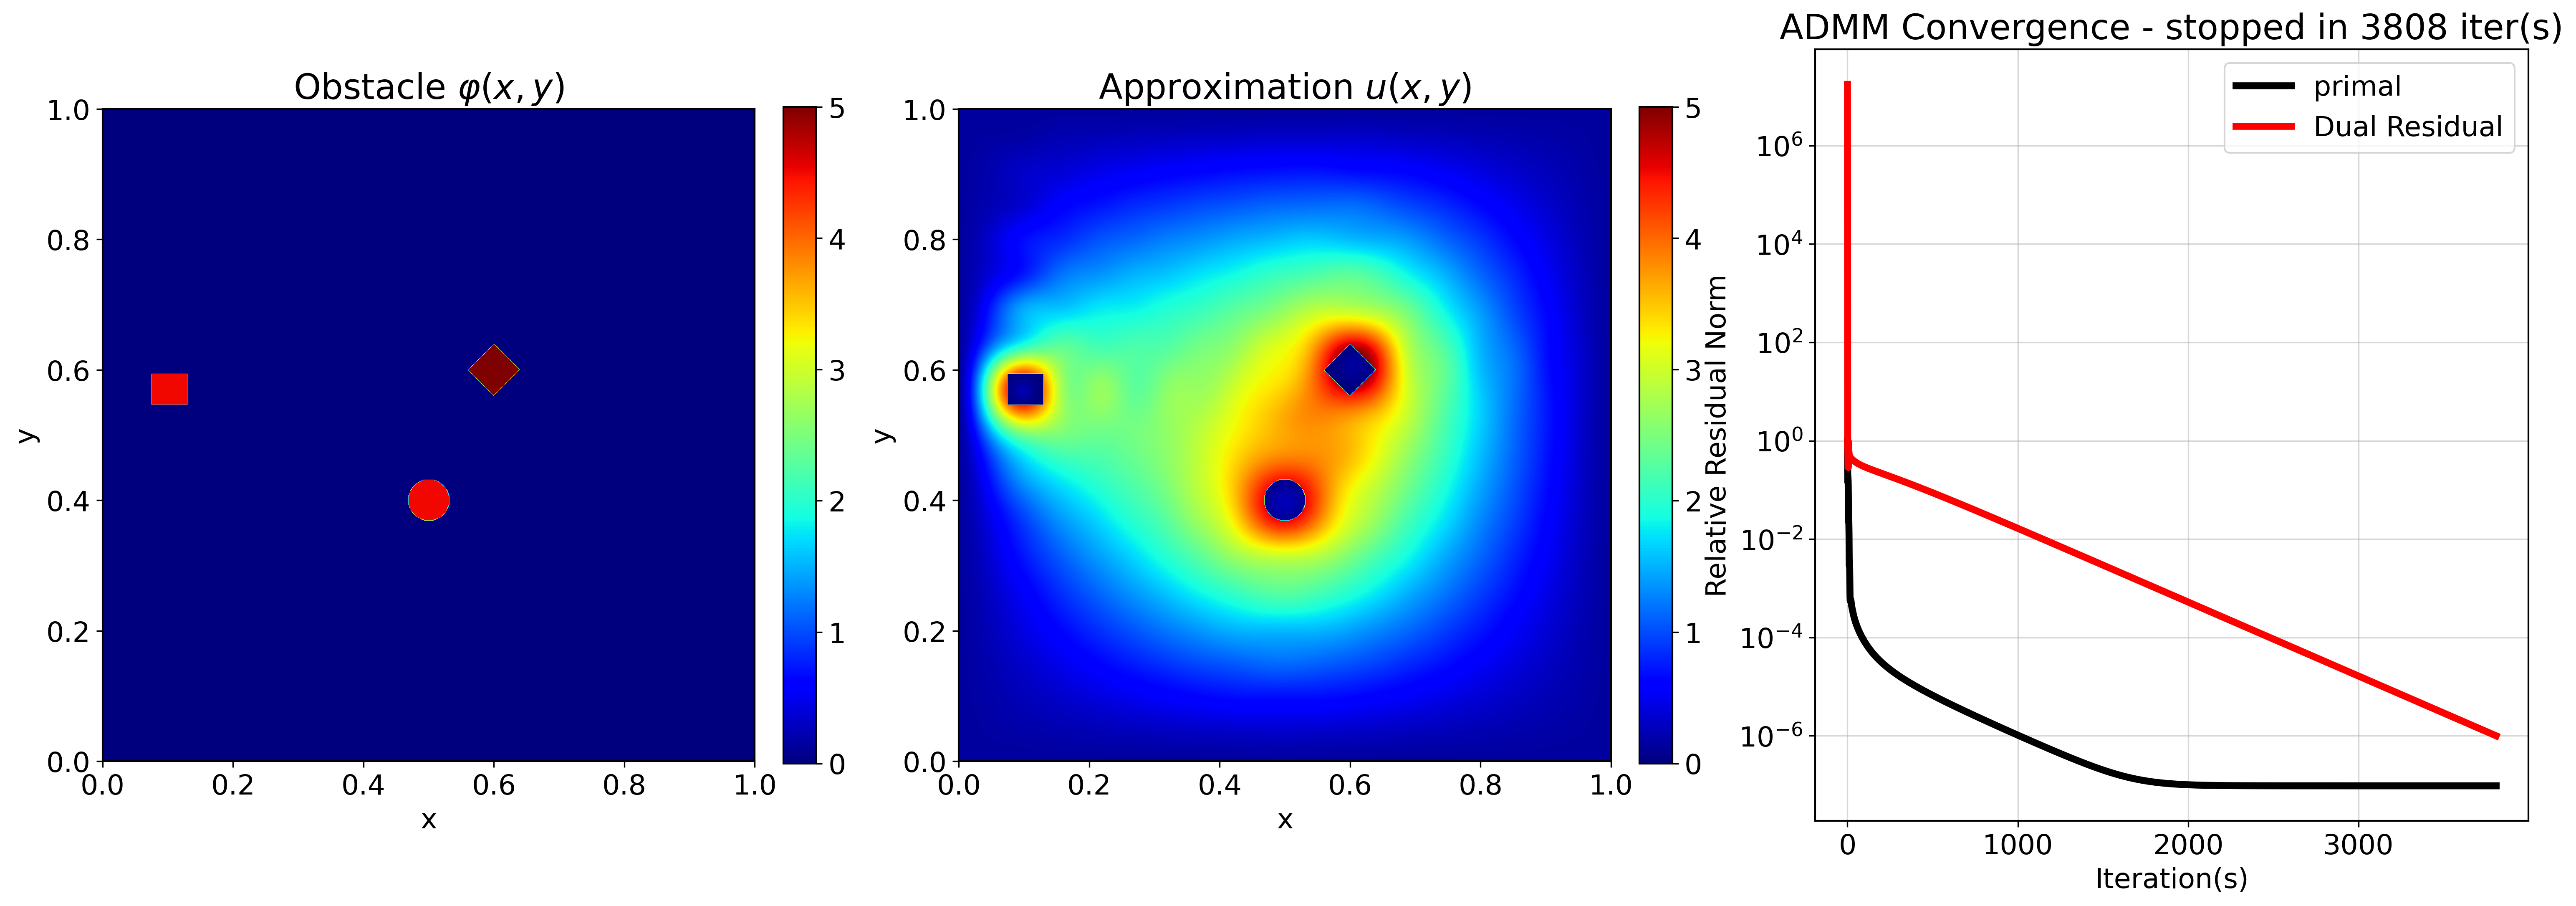

In [67]:



# Visualize ψ, u, and smooth gap
fig, axs = plt.subplots(1, 3, figsize=(25, 8), dpi = 300)
im0 = axs[0].imshow(Psi_plot, origin='lower', extent=[0,1,0,1], cmap = 'jet')
axs[0].set_title("Obstacle $\\varphi(x,y)$")
plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)
axs[0].set_xlabel('x'); axs[0].set_ylabel('y')

im1 = axs[1].imshow(gap_smooth, origin='lower', extent=[0,1,0,1], cmap = 'jet')
axs[1].set_title("Approximation $u(x,y)$")
plt.colorbar(im0, ax=axs[1], fraction=0.046, pad=0.04)
axs[1].set_xlabel('x'); axs[1].set_ylabel('y')

axs[2].semilogy(primal_residuals, label = 'primal', color = 'black')
axs[2].semilogy(dual_residuals, label='Dual Residual', color = 'red')
axs[2].set_title(f'ADMM Convergence - stopped in {it + 1:d} iter(s)')
axs[2].set_xlabel('Iteration(s)'); axs[2].set_ylabel('Relative Residual Norm')
axs[2].legend(); axs[2].grid(True)


#im2 = axs[2].imshow(gap_smooth, origin='lower', extent=[0,1,0,1], cmap = 'jet')
#axs[2].set_title("Contact Region $(u - \psi)_{+}$")
#plt.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)

plt.savefig('./Outputs/2D_Obstacle/Psi_Disjoint/fig1_obstacle_2D_disjoint.png')
plt.show()

Number of Basis Function(s): 400
Plot Grid Size (m x m): (800 x 800)


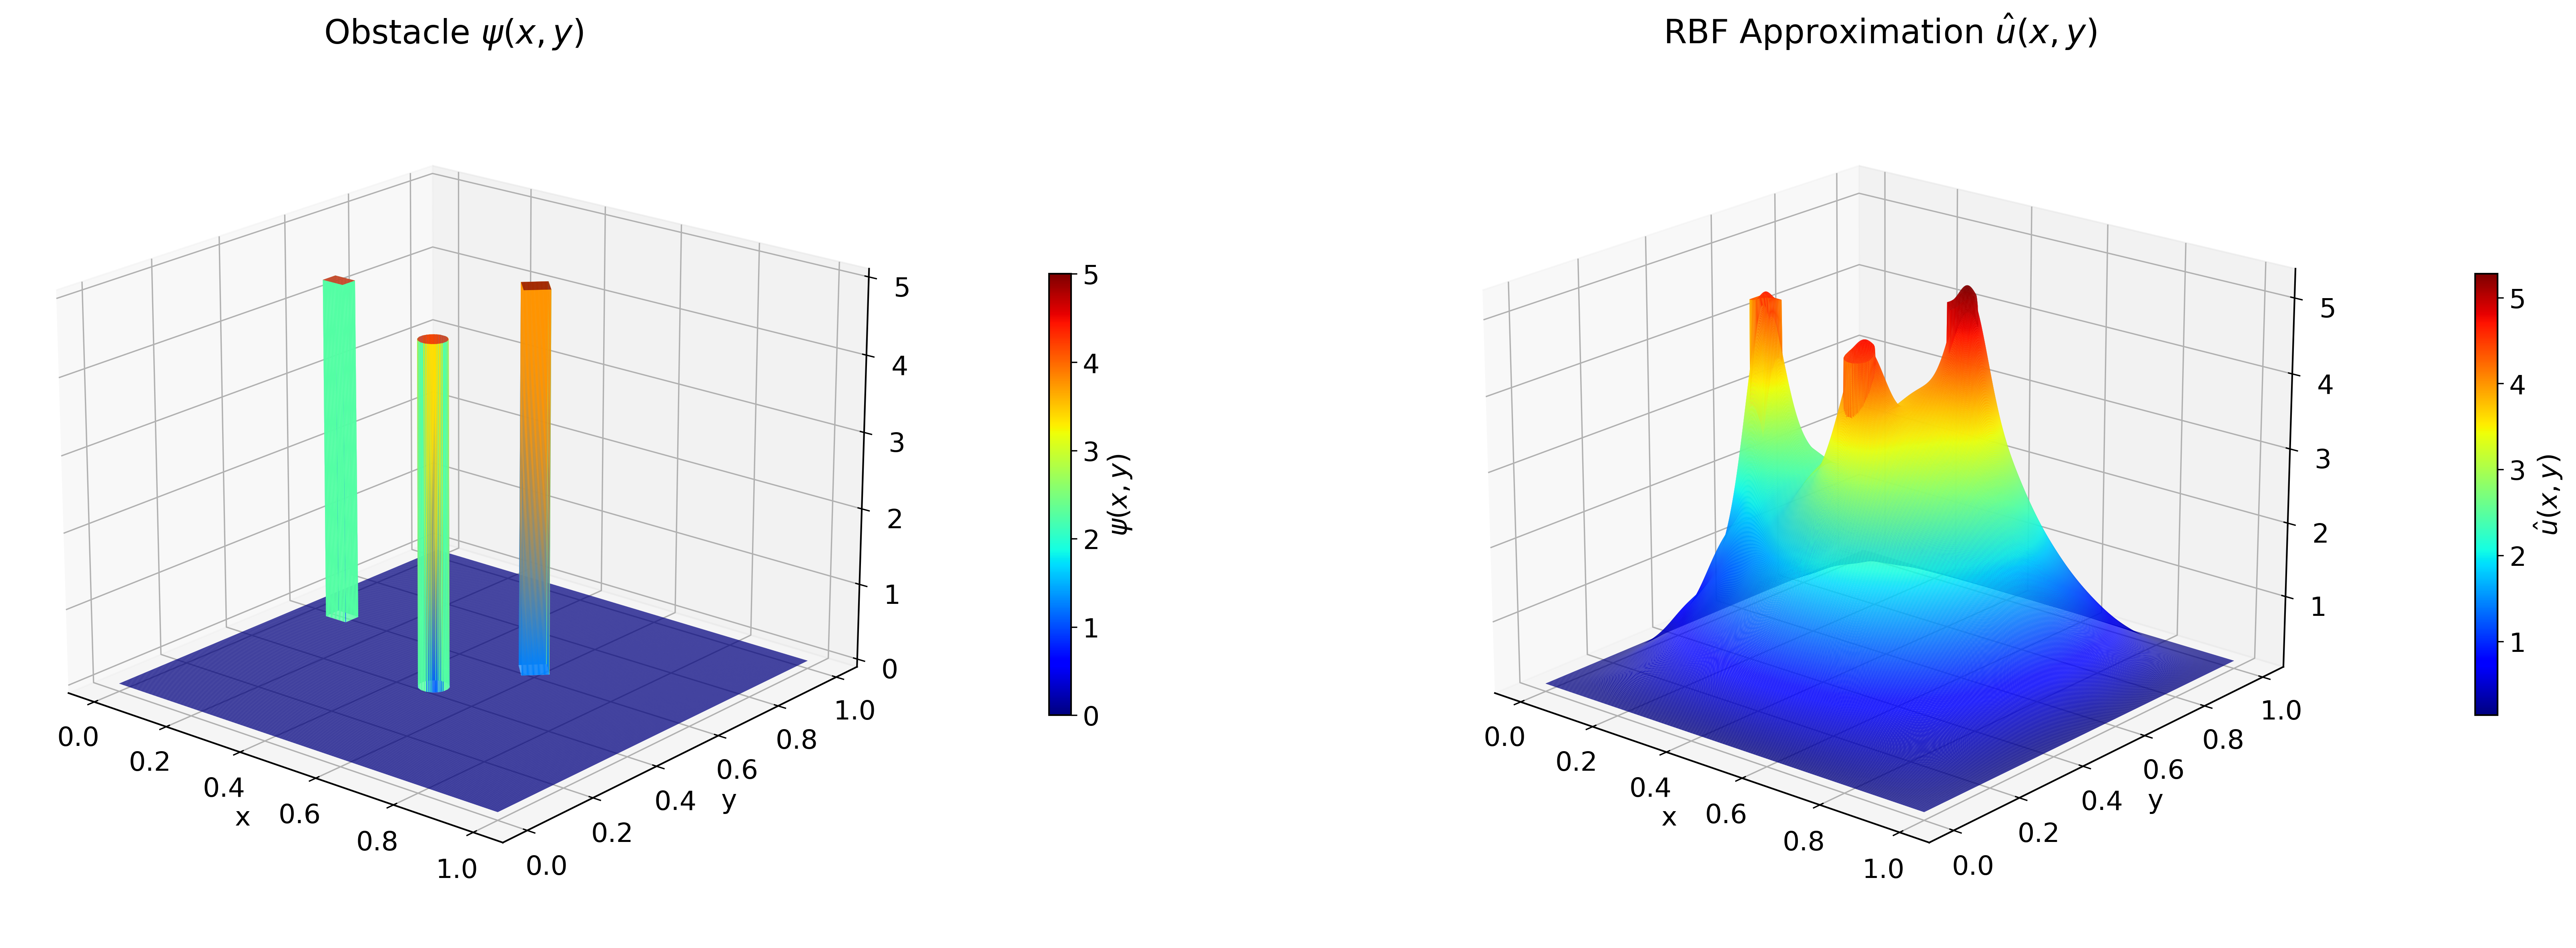

In [74]:
# -------------------------
# Plots (consistent with the updated solver variables)
# -------------------------
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401



plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.labelsize': 16,
    'axes.titlesize': 20,
    'axes.linewidth': 1.0,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'lines.linewidth': 4.0,
    'grid.linestyle': '-',
    'grid.alpha': 0.5,
    'figure.dpi': 300,
})

print(f'Number of Basis Function(s): {N}')
print(f'Plot Grid Size (m x m): ({M_plot} x {M_plot})')

fig = plt.figure(figsize=(25, 8), dpi = 300)

# Row 1: 3D Obstacle Function
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(X_plot, Y_plot, Psi_plot, cmap='jet', edgecolor='none',cstride = 1, rstride = 1)
ax1.set_title('Obstacle $\\psi(x,y)$')
ax1.set_xlabel('x'); ax1.set_ylabel('y')
ax1.view_init(elev=20, azim=-50)
fig.colorbar(surf, ax=ax1, shrink=0.5, pad=0.1, label='$\\psi(x,y)$')


# Row 2: 3D Approximation
ax3 = fig.add_subplot(1, 2, 2, projection='3d')
surf_3 = ax3.plot_surface(X_plot, Y_plot, gap_smooth + Psi_plot, cmap='jet', edgecolor='none',cstride = 1, rstride = 1)
ax3.set_title('RBF Approximation $\\hat{u}(x,y)$')
ax3.set_xlabel('x'); ax3.set_ylabel('y')
ax3.view_init(elev=20, azim=-50)
fig.colorbar(surf_3, ax=ax3, shrink=0.5, pad=0.1, label='$\\hat{u}(x,y)$')

plt.tight_layout()
plt.savefig('./Outputs/2D_Obstacle/Psi_Disjoint/fig2_obstacle_2D_disjoint.png')
plt.show()


# Benchmark Performance

In [15]:
import numpy as np
import time
import tracemalloc
from numpy.linalg import svd, norm
from numba import njit

def solve_rbf_admm(N_side, T=2, mu=6.5e5, rho=1.3e4,
                   max_iter=20_000, tau=1e-15, tol=5e-5,
                   L=1.0, beta=3e5, c = 1/20):
    # start tracking
    tracemalloc.start()
    t0 = time.perf_counter()

    # setup sizes
    N = N_side**2
    M_side = int(np.sqrt(T * N))
    M = M_side**2
    b = c * N

    # build points
    x = np.linspace(0, L, M_side)
    X, Y = np.meshgrid(x, x)
    pts = np.column_stack((X.ravel(), Y.ravel()))
    cx = np.linspace(0, L, N_side)
    CY, CX = np.meshgrid(cx, cx)
    centers = np.column_stack((CX.ravel(), CY.ravel()))

    # obstacle and boundary funcs
    def psi(xy, w=0.02, h_piece=1.0,  h_circle=0.75, r_circle=np.sqrt(0.005)):
      """
      Piece-wise block + circular bumps on [0,1]^2:
      """
      x, y = xy[:,0], xy[:,1]
      psi_vals = np.zeros_like(x)

      # Left block region
      mask_left = (np.abs(x-0.8) + np.abs(y - 0.6) <= w)
      psi_vals[mask_left] = h_piece



      # Circular bump region
      dx = x - 0.60
      dy = y - 0.25
      mask_circle = (dx*dx + dy*dy) < r_circle**2
      psi_vals[mask_circle] = h_circle

      return psi_vals

    psi_vals = psi(pts)

    # -------------------------
    # RBF Kernel
    # -------------------------


    # fast RBF
    @njit
    def rbf_fast(xy, centers, b):
        M_, N_ = xy.shape[0], centers.shape[0]
        out = np.empty((M_, N_))
        for i in range(M_):
            for j in range(N_):
                dx = xy[i,0]-centers[j,0]; dy = xy[i,1]-centers[j,1]
                out[i,j] = np.exp(-b*b*(dx*dx+dy*dy))
        return out

    Phi = rbf_fast(pts, centers, b)/np.sqrt(N)
    dx = L/(M_side-1)
    A1 = dx*dx*(Phi.T@Phi)

    bc_mask = (pts[:,0]==0)|(pts[:,0]==L)|(pts[:,1]==0)|(pts[:,1]==L)
    Phi_bc = Phi[bc_mask]
    gb = np.zeros(np.sum(bc_mask)) # zero boundary conditions.

    # system matrix
    A_mat = A1 + beta*(Phi_bc.T@Phi_bc) + rho*(Phi.T@Phi)

    # precompute SVD
    U,S,VT = svd(A_mat, full_matrices=False)
    thresh = tau*S.max()
    Sinv = np.where(S>thresh, 1/S, 0)
    def solve_svd(rhs):
        return VT.T @ (Sinv*(U.T@rhs))

    # ADMM initialize
    w = np.zeros(N); v = Phi@w; z = np.zeros(M)
    psi_vals = psi(pts)

    for it in range(max_iter):
        rhs = rho*(Phi.T@(v-z)) + beta*(Phi_bc.T@gb)
        w_new = solve_svd(rhs)
        proj = Phi@w_new + z
        v_new = np.maximum(proj - mu*dx*dx/rho, psi_vals)
        z_new = z + (Phi@w_new - v_new)

        # check convergence
        if norm(Phi@w_new - v_new)<tol and norm(rho*(Phi.T@(v_new-v)))<tol:
            break
        w,v,z = w_new,v_new,z_new

    # compute error
    u_approx = (Phi@w).reshape(M_side, M_side)


    # stop tracking
    comp_time = time.perf_counter()-t0
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    memory_usage = peak / 1024**2

    return N, M, memory_usage, comp_time

In [17]:
# Define the list of N_side values you want to benchmark
N_sides = [2, 5, 10, 15, 20, 25, 30, 35]
c_vals = [1/20,1/20, 1/20, 1/20, 1/20, 1/20, 1/20, 1/20]

# Prepare an empty list to collect results
results = []

for (Ns, c_val) in zip(N_sides, c_vals):
    # Run the solver: returns (rel_error, memory_MB, time_sec, M_grid)
    N, m, mem, t= solve_rbf_admm(Ns, c = c_val)
    print(f'N: {N:2d} | Gridsize: (m x m) = ({m:2d} x {m:2d}) | Memory Storage (MB): {mem:.3f} | Comp. Time (sec.): {t:.3f}')

    # Append a tuple (or dict) with all metrics
    results.append({
        'N':         N,
        'm_grid':    m,
        'memory_MB': mem,
        'comp_time':  t
    })



N:  4 | Gridsize: (m x m) = ( 4 x  4) | Memory Storage (MB): 1.476 | Comp. Time (sec.): 0.571
N: 25 | Gridsize: (m x m) = (49 x 49) | Memory Storage (MB): 1.478 | Comp. Time (sec.): 0.581
N: 100 | Gridsize: (m x m) = (196 x 196) | Memory Storage (MB): 1.560 | Comp. Time (sec.): 8.254
N: 225 | Gridsize: (m x m) = (441 x 441) | Memory Storage (MB): 3.896 | Comp. Time (sec.): 12.154
N: 400 | Gridsize: (m x m) = (784 x 784) | Memory Storage (MB): 9.082 | Comp. Time (sec.): 5.524
N: 625 | Gridsize: (m x m) = (1225 x 1225) | Memory Storage (MB): 19.945 | Comp. Time (sec.): 18.679
N: 900 | Gridsize: (m x m) = (1764 x 1764) | Memory Storage (MB): 39.595 | Comp. Time (sec.): 98.208
N: 1225 | Gridsize: (m x m) = (2401 x 2401) | Memory Storage (MB): 71.727 | Comp. Time (sec.): 68.115


Memory fit: MB = 1.221e-05·m^2 + 1.457e+00
Time fit: Time = 8.696e-02·N^0.891


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

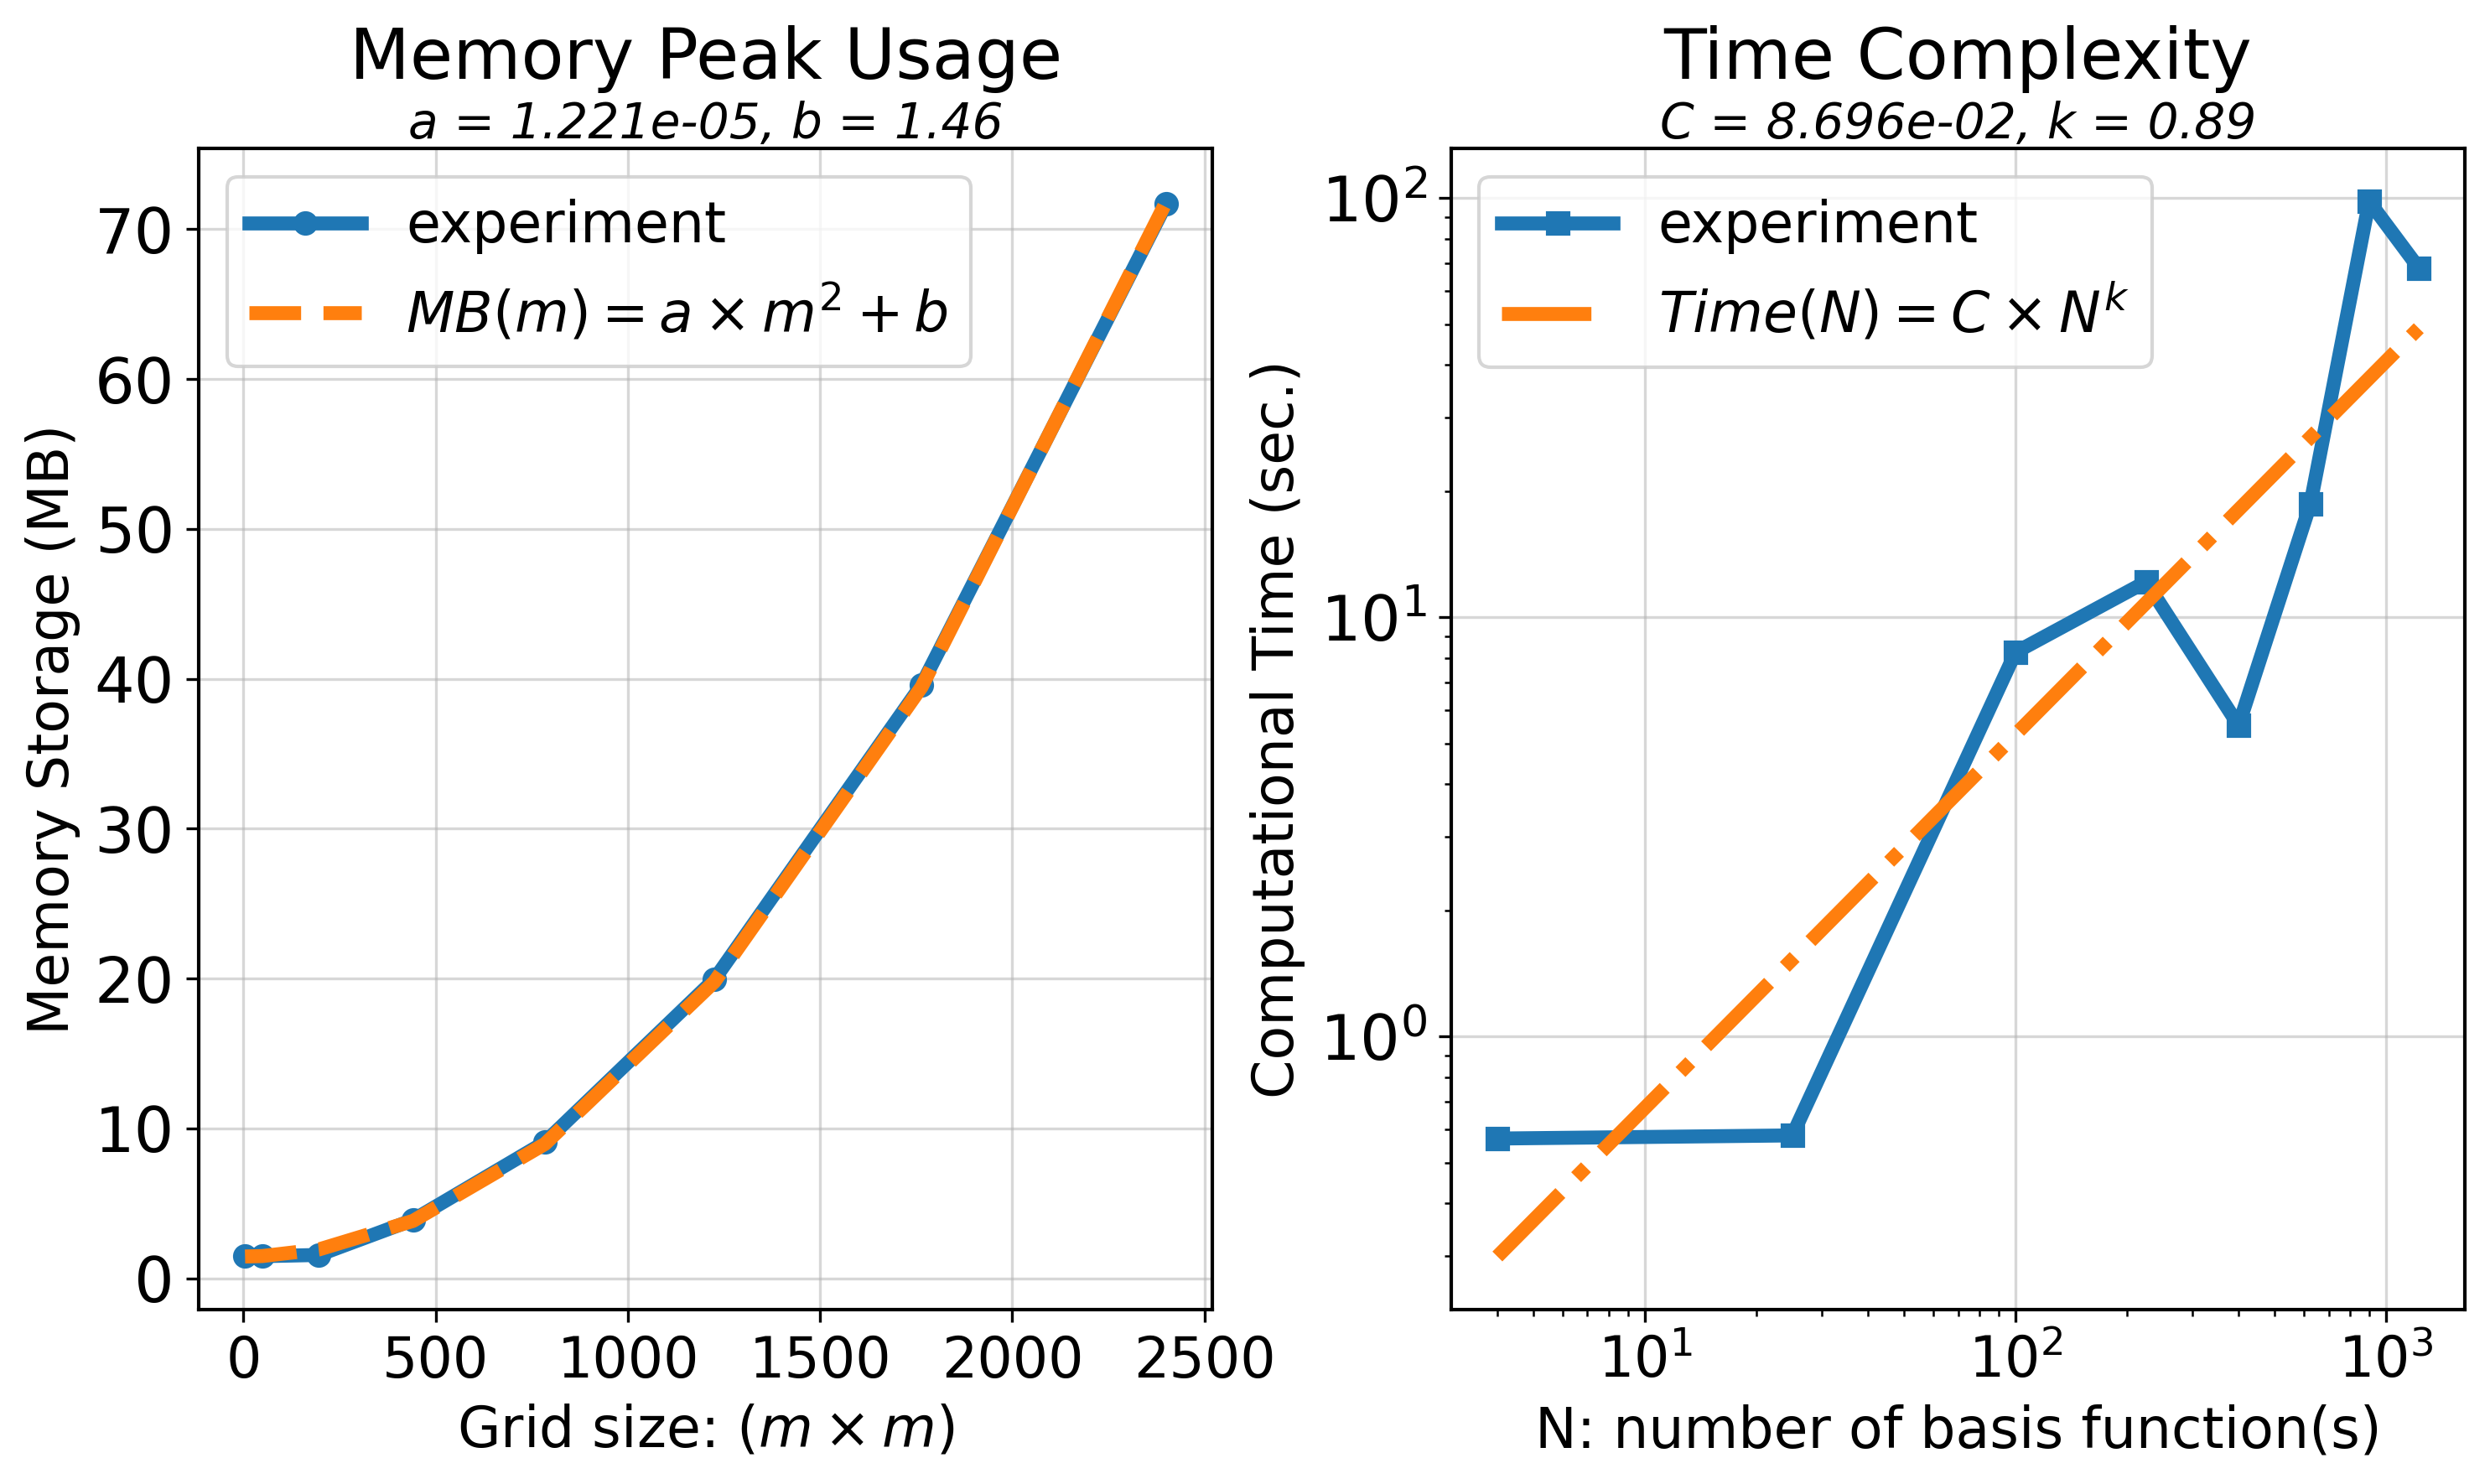

In [22]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from google.colab import files
import numpy as np


plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.labelsize': 16,
    'axes.titlesize': 20,
    'axes.linewidth': 1.0,
    'xtick.labelsize': 16,
    'ytick.labelsize': 18,
    'legend.fontsize': 16,
    'lines.linewidth': 4.0,
    'grid.linestyle': '-',
    'grid.alpha': 0.5,
    'figure.dpi': 300,
})


# Assuming `results` is a list of dicts with keys:
# 'N', 'M_grid', 'memory_MB', 'time_sec', 'rel_error'

# Extract data
m_vals      = np.array([r['m_grid']    for r in results])
memory_vals = np.array([r['memory_MB'] for r in results])
N_vals      = np.array([r['N']         for r in results])
time_vals   = np.array([r['comp_time']  for r in results])



# 1. Memory ~ a * M^2 + b
X1 = np.vstack([m_vals**2, np.ones_like(m_vals)]).T
a, b = np.linalg.lstsq(X1, memory_vals, rcond=None)[0]
print(f"Memory fit: MB = {a:.3e}·m^2 + {b:.3e}")

# 2. Time ~ C * N^k (log–log fit)
lnN, lnt = np.log(N_vals), np.log(time_vals)
k, lnC = np.polyfit(lnN, lnt, 1)
C = np.exp(lnC)
print(f"Time fit: Time = {C:.3e}·N^{k:.3f}")




# Create figure and gridspec
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6), tight_layout=True)

# Top-left: Memory vs Grid Size

ax1.plot(m_vals, memory_vals, 'o-', linewidth=4, color = 'tab:blue', label = 'experiment')
ax1.plot(m_vals, a * m_vals**2 + b, '--', linewidth=4, color = 'tab:orange', label = f'$MB(m) = a \\times m^2 + b$')
ax1.legend(frameon = True)
ax1.set_xlabel(f'Grid size: $(m \\times m)$')
ax1.set_ylabel('Memory Storage (MB)')
ax1.set_title('Memory Peak Usage', pad = 20)
ax1.text(
    0.5, 1.0,
    f'a = {a:.3e}, b = {b:.2f}',
    transform=ax1.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontstyle="italic"
)

ax1.grid(True)

# Top-right: Time Complexity (log-log)

ax2.loglog(N_vals, time_vals, 's-', linewidth=4, label = 'experiment', color = 'tab:blue')
ax2.loglog(N_vals, C * N_vals**k, '-.', linewidth=4, label = f'$Time(N) = C \\times N^k$', color = 'tab:orange')
ax2.legend(frameon = True)
ax2.set_xlabel('N: number of basis function(s)')
ax2.set_ylabel('Computational Time (sec.)')
ax2.set_title('Time Complexity', pad = 20)
ax2.text(
    0.5, 1.0,
    f'C = {C:.3e}, k = {k:.2f}',
    transform=ax2.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontstyle="italic"
)
ax2.grid(True)


plt.tight_layout()
plt.savefig('fig2_obstacle_2D_piecewise.png')
files.download('fig2_obstacle_2D_piecewise.png')